# dmpbridge — Comparison Dashboard

Central view across all models and inference strategies.

| Model | Provider | Strategy |
|---|---|---|
| llama3.3:70b | Ollama (local) | Batched |
| llama3.1:8b | Ollama (local) | Batched |
| claude-opus-4-8 | Anthropic | Batched |
| claude-opus-4-8 | Anthropic | Whole-document |

| Section | Content |
|---|---|
| 1 | Executive summary |
| 2 | Per-sample accuracy |
| 3 | Per-label F1 |
| 4 | Cross-model agreement |
| 5 | Error drill-down |

## Setup

In [1]:
import sys
sys.path.insert(0, "..")

from evaluate import extract_gold, evaluate_sample, match, LABELS, SHORT, LLM_DIR, MANUAL_DIR, NO_MATCH
import json
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "axes.edgecolor":"#555555", "axes.linewidth":0.8,
    "grid.color":"#dddddd",    "grid.linewidth":0.5,
    "text.color":"#111111",    "axes.labelcolor":"#111111",
    "xtick.color":"#111111",   "ytick.color":"#111111",
    "font.size":11, "axes.titlesize":13, "axes.labelsize":11,
    "xtick.labelsize":10, "ytick.labelsize":10,
    "legend.fontsize":10, "legend.frameon":True, "legend.edgecolor":"#cccccc",
    "figure.dpi":120,
})

# ── Model registry ─────────────────────────────────────────────────────────────
# Each entry: display_name -> (file_tag, hex_color, provider_group)
MODELS = {
    "llama3.3-70b":         ("llama3.3-70b",                "#1d4ed8", "Ollama"),
    "llama3.1-8b":          ("llama3.1-8b",                 "#60a5fa", "Ollama"),
    "claude (batched)":     ("claude-opus-4-8",             "#7c3aed", "Anthropic"),
    "claude (whole-doc)":   ("claude-opus-4-8-wholedoc",   "#c084fc", "Anthropic"),
}

PROVIDER_COLORS = {"Ollama": "#dbeafe", "Anthropic": "#ede9fe"}

def _snum(p):
    s = p.stem if hasattr(p, "stem") else p
    return int(s.replace("_dmp", "").replace("sample", ""))

samples = sorted(MANUAL_DIR.glob("*_dmp.json"), key=_snum)

def _f1(conf, lbl):
    tp = conf.get(lbl, {}).get(lbl, 0)
    fp = sum(conf.get(o, {}).get(lbl, 0) for o in LABELS if o != lbl)
    fn = sum(v for p, v in conf.get(lbl, {}).items() if p != lbl)
    p_ = tp / (tp + fp) if (tp + fp) else 0.
    r_ = tp / (tp + fn) if (tp + fn) else 0.
    return 2 * p_ * r_ / (p_ + r_) if (p_ + r_) else 0.

def load_variant(tag):
    rows, conf = [], defaultdict(lambda: defaultdict(int))
    for mp in samples:
        stem = mp.stem.replace("_dmp", "")
        pp   = LLM_DIR / f"{stem}_{tag}.json"
        if not pp.exists():
            continue
        gold = extract_gold(mp)
        c    = evaluate_sample(pp, gold)
        for tl, preds in c.items():
            for pl, cnt in preds.items():
                conf[tl][pl] += cnt
        tp = sum(c.get(l, {}).get(l, 0) for l in LABELS)
        n  = sum(sum(v.values()) for v in c.values())
        rows.append({"sample": stem, "total": n, "correct": tp,
                     "errors": n - tp, "accuracy": tp / n if n else 0})
    return pd.DataFrame(rows), conf

variants = {name: load_variant(tag) for name, (tag, color, grp) in MODELS.items()}

print("Loaded variants:")
for name, (df, _) in variants.items():
    tag, color, grp = MODELS[name]
    if df.empty: print(f"  MISSING  [{grp}] {name}"); continue
    tc, tn = int(df["correct"].sum()), int(df["total"].sum())
    print(f"  [{grp:<9}] {name:<22}  {tc}/{tn}  ({tc/tn*100:.1f}%)")

Loaded variants:
  [Ollama   ] llama3.3-70b            697/741  (94.1%)
  [Ollama   ] llama3.1-8b             499/741  (67.3%)
  [Anthropic] claude (batched)        703/741  (94.9%)
  [Anthropic] claude (whole-doc)      718/741  (96.9%)


## 1 — Executive Summary

In [2]:
print("=" * 90)
print("  dmpbridge — Model Comparison")
print("=" * 90)
hdr = f"  {'Provider':<11}  {'Model / Strategy':<24}  {'Accuracy':>8}  {'q.text F1':>10}  {'sec.desc F1':>12}  {'ans.text F1':>12}"
print("\n" + hdr)
print("  " + "-" * 82)

last_grp = None
for name, (df, conf) in variants.items():
    tag, color, grp = MODELS[name]
    if df.empty: continue
    if grp != last_grp:
        if last_grp is not None:
            print()
        last_grp = grp
    tc, tn = int(df["correct"].sum()), int(df["total"].sum())
    acc   = tc / tn * 100
    f1_qt = _f1(conf, "question.text")     * 100
    f1_sd = _f1(conf, "section.description") * 100
    f1_at = _f1(conf, "answer.text")        * 100
    print(f"  {grp:<11}  {name:<24}  {acc:>7.1f}%  {f1_qt:>9.1f}%  {f1_sd:>11.1f}%  {f1_at:>11.1f}%")

print("=" * 90)

  dmpbridge — Model Comparison

  Provider     Model / Strategy          Accuracy   q.text F1   sec.desc F1   ans.text F1
  ----------------------------------------------------------------------------------
  Ollama       llama3.3-70b                 94.1%       70.7%         87.7%         99.0%
  Ollama       llama3.1-8b                  67.3%       26.1%         40.5%         80.2%

  Anthropic    claude (batched)             94.9%       62.0%         84.4%         99.9%
  Anthropic    claude (whole-doc)           96.9%       88.2%         99.1%         99.6%


## 2 — Per-sample accuracy

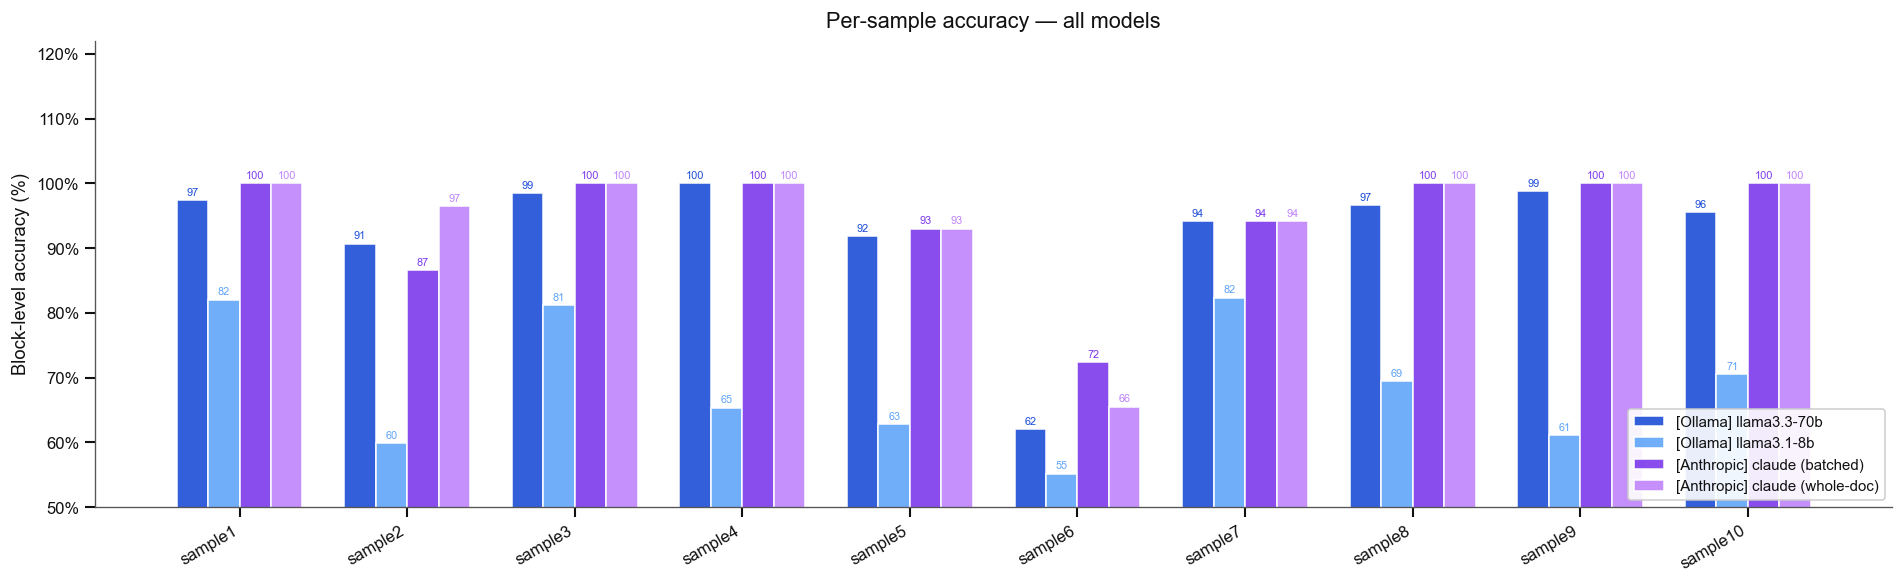

In [3]:
active  = {n: variants[n] for n in MODELS if not variants[n][0].empty}
n_mods  = len(active)
w       = 0.75 / n_mods
x_lbls  = sorted(next(iter(active.values()))[0]["sample"].tolist(), key=_snum)
x       = range(len(x_lbls))

fig, ax = plt.subplots(figsize=(16, 5))

for i, (name, (df, _)) in enumerate(active.items()):
    tag, color, grp = MODELS[name]
    dfs    = df.set_index("sample").reindex(x_lbls).reset_index()
    offset = (i - n_mods/2 + 0.5) * w
    bars   = ax.bar([xi + offset for xi in x], dfs["accuracy"] * 100,
                    width=w, label=f"[{grp}] {name}",
                    color=color, edgecolor="white", alpha=0.9)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                    f"{h:.0f}", ha="center", va="bottom", fontsize=6.5, color=color)

ax.set_xticks(list(x))
ax.set_xticklabels(x_lbls, rotation=30, ha="right")
ax.set_ylim(50, 122)
ax.set_ylabel("Block-level accuracy (%)")
ax.set_title("Per-sample accuracy — all models", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(framealpha=0.9, fontsize=9, loc="lower right")
sns.despine(); plt.tight_layout(); plt.show()

## 3 — Per-label F1

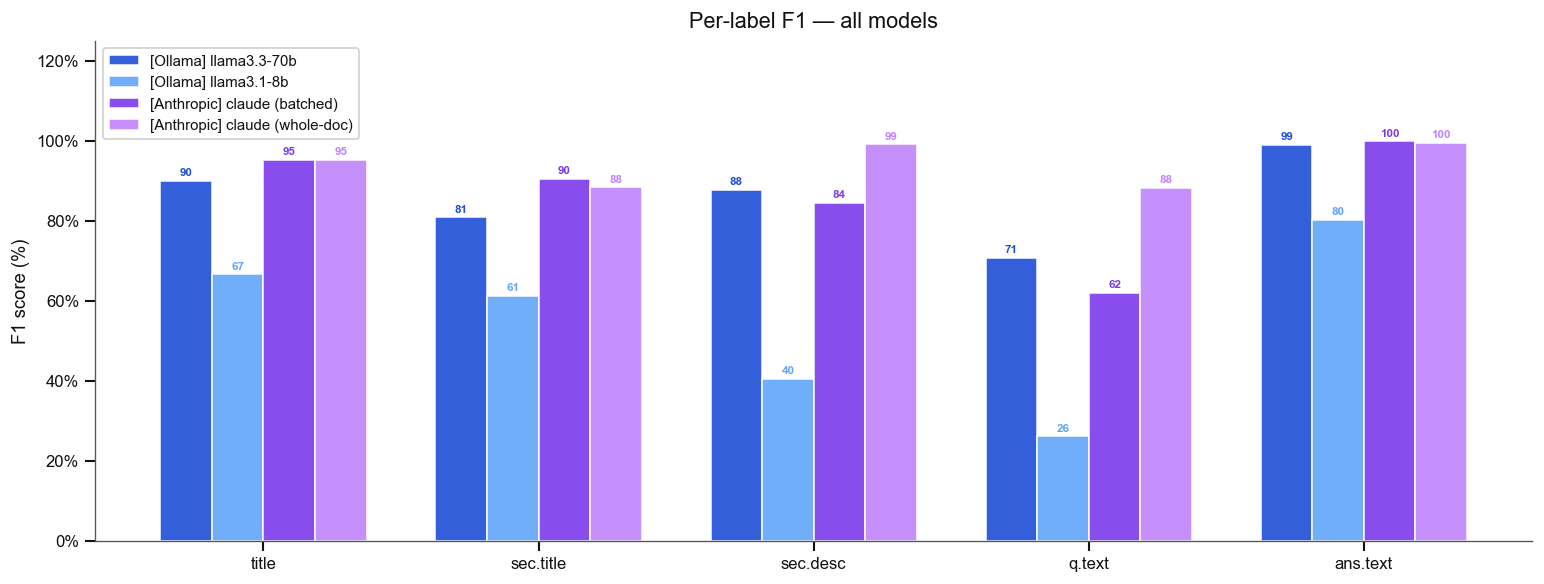


Label                             llama3.3-70b             llama3.1-8b        claude (batched)      claude (whole-doc)
----------------------------------------------------------------------------------------------------------------------
title                                    90.0%                   66.7%                   95.2%                   95.2%
section.title                            80.9%                   61.3%                   90.5%                   88.4%
section.description                      87.7%                   40.5%                   84.4%                   99.1%
question.text                            70.7%                   26.1%                   62.0%                   88.2%
answer.text                              99.0%                   80.2%                   99.9%                   99.6%
----------------------------------------------------------------------------------------------------------------------
OVERALL accuracy                         94.1% 

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
x2 = range(len(LABELS))
w2 = 0.75 / n_mods

for i, (name, (_, conf)) in enumerate(active.items()):
    tag, color, grp = MODELS[name]
    f1_vals = [_f1(conf, l) * 100 for l in LABELS]
    offset  = (i - n_mods/2 + 0.5) * w2
    bars = ax.bar([xi + offset for xi in x2], f1_vals,
                  width=w2, label=f"[{grp}] {name}",
                  color=color, edgecolor="white", alpha=0.9)
    for bar, v in zip(bars, f1_vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                    f"{v:.0f}", ha="center", va="bottom",
                    fontsize=7, fontweight="bold", color=color)

ax.set_xticks(list(x2))
ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylim(0, 125)
ax.set_ylabel("F1 score (%)")
ax.set_title("Per-label F1 — all models", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(framealpha=0.9, fontsize=9)
sns.despine(); plt.tight_layout(); plt.show()

# F1 table
print(f"\n{'Label':<22}" + "".join(f"  {n:>22}" for n in active))
print("-" * (22 + 24 * n_mods))
for lbl in LABELS:
    row = f"{lbl:<22}"
    for name, (_, conf) in active.items():
        row += f"  {_f1(conf, lbl)*100:>21.1f}%"
    print(row)
print("-" * (22 + 24 * n_mods))
row = f"{'OVERALL accuracy':<22}"
for name, (df, _) in active.items():
    ov = df['correct'].sum() / df['total'].sum() * 100
    row += f"  {ov:>21.1f}%"
print(row)

## 4 — Cross-model agreement

For each block, counts how many models (out of 4) labeled it correctly.

| Category | Meaning |
|---|---|
| **all correct** | All 4 models right |
| **3 correct** | Three right, one wrong |
| **2 correct** | Split decision |
| **1 correct** | Only one right |
| **all wrong** | Genuinely hard blocks |

In [5]:
tag_list    = [(n, MODELS[n][0]) for n in active]
cross_rows  = []

for mp in samples:
    stem = mp.stem.replace("_dmp", "")
    gold = extract_gold(mp)
    block_sets = {}
    for name, tag in tag_list:
        pp = LLM_DIR / f"{stem}_{tag}.json"
        if not pp.exists(): break
        block_sets[name] = json.loads(pp.read_text(encoding="utf-8"))
    else:
        ref = block_sets[tag_list[0][0]]
        for idx, b in enumerate(ref):
            true_lbl = match(b["text"], gold)
            if true_lbl is None: continue
            preds     = {n: block_sets[n][idx].get("label", "answer.text") for n, _ in tag_list}
            n_correct = sum(1 for p in preds.values() if p == true_lbl)
            row = {"sample": stem, "text": b["text"][:120],
                   "page": b.get("page", "-"), "true": true_lbl,
                   "n_correct": n_correct}
            for n, _ in tag_list:
                row[f"pred_{n.replace(' ','_')}"] = preds[n]
            cross_rows.append(row)

df_cross  = pd.DataFrame(cross_rows)
n_models  = len(active)
total     = len(df_cross)

print(f"Cross-model agreement  (total matched blocks: {total})\n")
for n in [n_models, n_models-1, n_models-2, 1, 0]:
    if n < 0: continue
    label_str = {n_models: "all correct", 0: "all wrong"}.get(n, f"{n} correct")
    cnt = (df_cross["n_correct"] == n).sum()
    pct = cnt / total * 100
    bar = "\u2588" * int(pct / 2)
    print(f"  {label_str:<14} {cnt:>4}  ({pct:>5.1f}%)  {bar}")

all_wrong_n = (df_cross["n_correct"] == 0).sum()
print(f"\nConclusion: {all_wrong_n} blocks are hard for ALL models.")

Cross-model agreement  (total matched blocks: 726)

  all correct     481  ( 66.3%)  █████████████████████████████████
  3 correct       213  ( 29.3%)  ██████████████
  2 correct        24  (  3.3%)  █
  1 correct         6  (  0.8%)  
  all wrong         2  (  0.3%)  

Conclusion: 2 blocks are hard for ALL models.


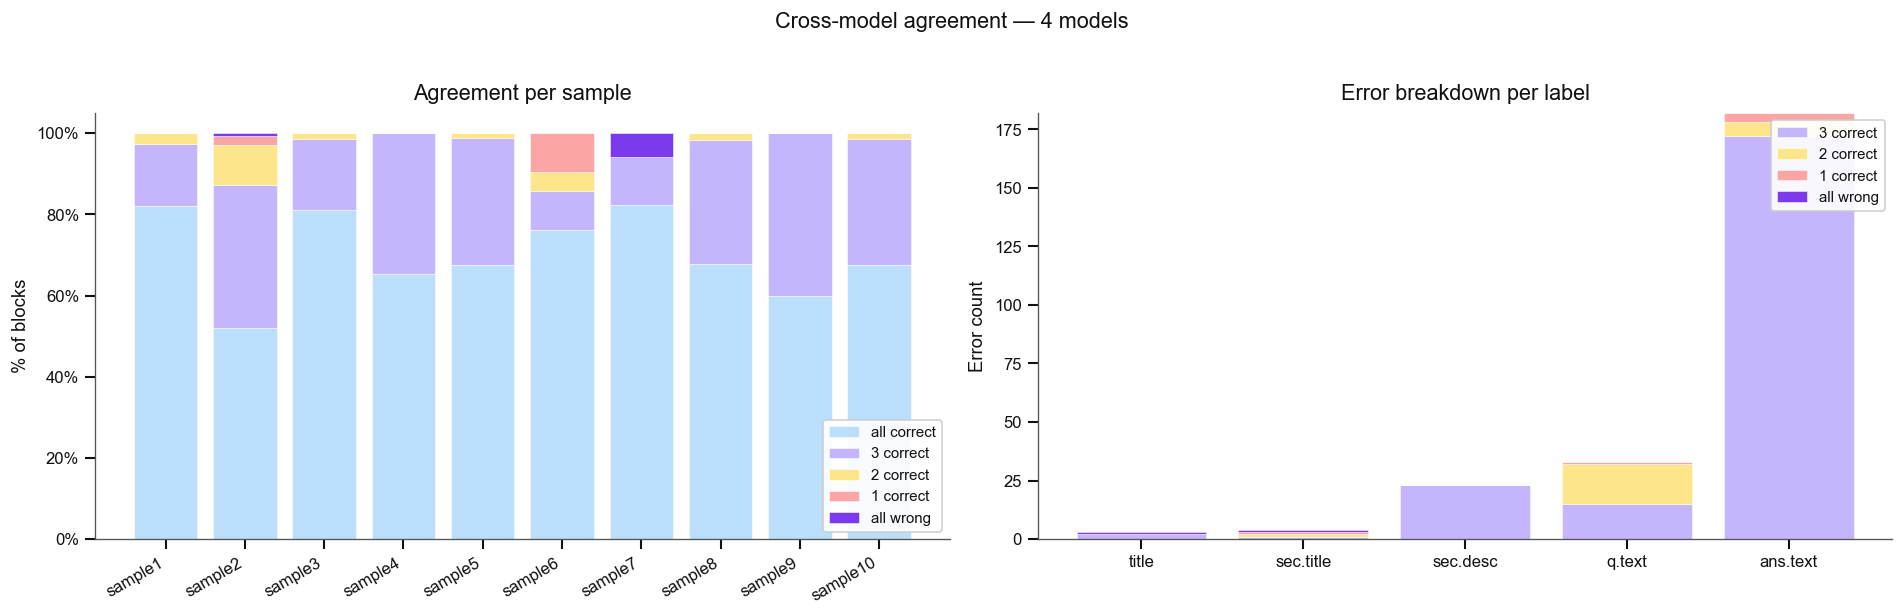

In [6]:
CAT_COLORS = {
    n_models:     "#bbdefb",
    n_models - 1: "#c4b5fd",
    n_models - 2: "#fde68a",
    1:            "#fca5a5",
    0:            "#7c3aed",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: stacked bar per sample ──────────────────────────────────────────────
ax = axes[0]
x_labels = sorted(df_cross["sample"].unique().tolist(), key=_snum)
bottoms  = {s: 0 for s in x_labels}
for n in [n_models, n_models-1, n_models-2, 1, 0]:
    if n < 0 or n not in CAT_COLORS: continue
    label_str = {n_models: "all correct", 0: "all wrong"}.get(n, f"{n} correct")
    vals = []
    for s in x_labels:
        sub = df_cross[df_cross["sample"] == s]
        cnt = (sub["n_correct"] == n).sum()
        vals.append(cnt / len(sub) * 100 if len(sub) else 0)
    ax.bar(x_labels, vals, bottom=[bottoms[s] for s in x_labels],
           label=label_str, color=CAT_COLORS[n], edgecolor="white", linewidth=0.3)
    for xi, (s, v) in enumerate(zip(x_labels, vals)):
        bottoms[s] += v

ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_ylim(0, 105); ax.set_ylabel("% of blocks")
ax.set_title("Agreement per sample", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(loc="lower right", framealpha=0.9, fontsize=9)
sns.despine(ax=ax)

# ── Right: per-label breakdown ────────────────────────────────────────────────
ax = axes[1]
x2  = range(len(LABELS))
btm = [0] * len(LABELS)
for n in [n_models-1, n_models-2, 1, 0]:
    if n < 0 or n not in CAT_COLORS: continue
    label_str = {0: "all wrong"}.get(n, f"{n} correct")
    vals = [(df_cross[df_cross["true"] == l]["n_correct"] == n).sum() for l in LABELS]
    ax.bar(x2, vals, bottom=btm, label=label_str,
           color=CAT_COLORS[n], edgecolor="white", linewidth=0.3)
    btm = [b + v for b, v in zip(btm, vals)]

ax.set_xticks(list(x2)); ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylabel("Error count")
ax.set_title("Error breakdown per label", pad=8)
ax.legend(loc="upper right", framealpha=0.9, fontsize=9)
sns.despine(ax=ax)

plt.suptitle(f"Cross-model agreement — {n_models} models", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [7]:
# Blocks all models got wrong
all_wrong_df = df_cross[df_cross["n_correct"] == 0].copy()
pred_cols    = [c for c in all_wrong_df.columns if c.startswith("pred_")]
if all_wrong_df.empty:
    print("No blocks that all models got wrong.")
else:
    print(f"Blocks all {n_models} models got wrong ({len(all_wrong_df)} blocks)\n")
    pd.set_option("display.max_colwidth", 90)
    display(all_wrong_df[["sample", "page", "true"] + pred_cols + ["text"]]
            .sort_values(["true", "sample"]).reset_index(drop=True))

Blocks all 4 models got wrong (2 blocks)



,sample,page,true,pred_llama3.3-70b,pred_llama3.1-8b,pred_claude_(batched),pred_claude_(whole-doc),text
0,sample2,5,section.title,section.description,answer.text,section.description,section.description,data.
1,sample7,1,title,section.title,section.title,section.title,section.title,Resource/Data Sharing Plan


## 5 — Error Drill-Down

Edit the filter variables to inspect any subset of errors.

In [8]:
# ── Edit these ────────────────────────────────────────────────────────────────
FILTER_MODEL   = "claude (whole-doc)"   # any display name from MODELS, or "" for all
FILTER_TRUE    = "question.text"         # label or "" for all
FILTER_PRED    = ""                      # label or "" for all
FILTER_SAMPLE  = ""                      # e.g. "sample2" or "" for all
ONLY_ERRORS    = True

# ── Apply filter ──────────────────────────────────────────────────────────────
pred_col = f"pred_{FILTER_MODEL.replace(' ', '_')}" if FILTER_MODEL else None
if pred_col and pred_col not in df_cross.columns:
    print(f"Model '{FILTER_MODEL}' not found. Available: {list(active.keys())}")
    pred_col = None

mask = pd.Series([True] * len(df_cross), index=df_cross.index)
if ONLY_ERRORS:
    if pred_col:
        mask &= df_cross[pred_col] != df_cross["true"]
    else:
        mask &= df_cross["n_correct"] < n_models
if FILTER_TRUE:   mask &= df_cross["true"]    == FILTER_TRUE
if FILTER_PRED and pred_col:
    mask &= df_cross[pred_col] == FILTER_PRED
if FILTER_SAMPLE: mask &= df_cross["sample"]  == FILTER_SAMPLE

subset    = df_cross[mask].reset_index(drop=True)
pred_cols = [c for c in df_cross.columns if c.startswith("pred_")]
print(f"Filter: model={FILTER_MODEL or 'all'}  true={FILTER_TRUE or 'any'}  "
      f"pred={FILTER_PRED or 'any'}  sample={FILTER_SAMPLE or 'all'}  only_errors={ONLY_ERRORS}")
print(f"Matching blocks: {len(subset)}\n")
if not subset.empty:
    pd.set_option("display.max_colwidth", 90)
    display(subset[["sample", "page", "true", "n_correct"] + pred_cols + ["text"]])

Filter: model=claude (whole-doc)  true=question.text  pred=any  sample=all  only_errors=True
Matching blocks: 0

